# Assignment 1

Note: This notebook file for the assignment has deviations from the course guide with respect to the structure, sentence framing, question framing and numbering. Please consider this notebook file structure as the final structure and follow this.

In this assignment, you will explore the CIFAR10 dataset. 

You have to download the dataset from Pytorch.

Comment your code and indicate what the different instructions are doing and what you are showing and printing. 
When printing figures do not forget about the title, x and y labels. The font size should be matching the text size of the text in your report. 
Do not forget to add legends to the plots. 

In [1]:
%pip install torchvision # install torchvision to use PyTorch do download the dataset

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


------------------------

In [2]:
# Load all the needed packages for this assignment here
import matplotlib.pyplot as plt
import numpy as np


#### Exercise 1.1 - Load data

**a)** Load the CIFAR10 dataset. 

**b)** Print the number of samples and the number of classes present in the dataset. 

**c)** Also print the shape of an image in the dataset. 

Number of traning images: 50000
Number of test images: 10000
Total number of images: 60000

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Number of classes: 10

Shape of the first image in the dataset: (32, 32)


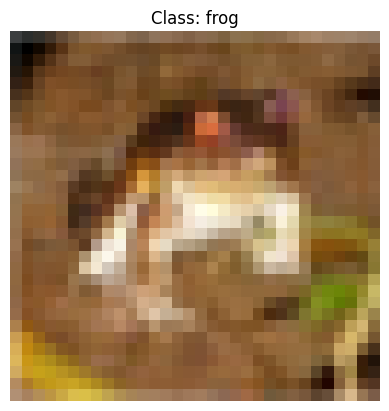

In [3]:
# Ex.1.1a,b & c
import torchvision

# Load the CIFAR-10 dataset (training and test sets). The dataset is downloaded from the internet and stored in the 'data' folder in the current dictionary.
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=None)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=None)

# Print the number of images in the training and test sets and in total
print(f'Number of traning images: {len(trainset)}')
print(f'Number of test images: {len(testset)}')
print(f'Total number of images: {len(trainset)+len(testset)}\n')

# Print the classes + the number of classes in the dataset
classes = trainset.classes
print(f'Classes: {classes}')
print(f'Number of classes: {len(classes)}\n')

# Print the shape of an first image in the dataset
image, label = trainset[0]
print(f"Shape of the first image in the dataset: {image.size}")

# Display the first image in the dataset
plt.imshow(image)
plt.title(f"Class: {classes[label]}")
plt.axis('off')
plt.show()

#### Exercise 1.2 - Quantify dataset

**a)** Print the number of samples per category.

In [4]:
from collections import Counter

# Count the number of samples per category in the training set
train_labels = [label for _, label in trainset]
train_labels_count = Counter(train_labels)
# Map the class indices to class names
train_labels_count_named = {classes[label]: count for label, count in train_labels_count.items()}
print(f'The number of samples per category in the traning set \n{train_labels_count_named}')

# Count the number of samples per category in the test set
test_labels = [label for _, label in testset]
test_labels_count = Counter(test_labels)
# Map the class indices to class names
test_labels_count_named = {classes[label]: count for label, count in test_labels_count.items()}
print(f'\nThe number of samples per category in the test set \n{test_labels_count_named}')

The number of samples per category in the traning set 
{'frog': 5000, 'truck': 5000, 'deer': 5000, 'automobile': 5000, 'bird': 5000, 'horse': 5000, 'ship': 5000, 'cat': 5000, 'dog': 5000, 'airplane': 5000}

The number of samples per category in the test set 
{'cat': 1000, 'ship': 1000, 'airplane': 1000, 'frog': 1000, 'automobile': 1000, 'truck': 1000, 'dog': 1000, 'horse': 1000, 'deer': 1000, 'bird': 1000}


**b)** Plot the number of samples per category using a bar plot.

Text(0.5, 0, 'Category')

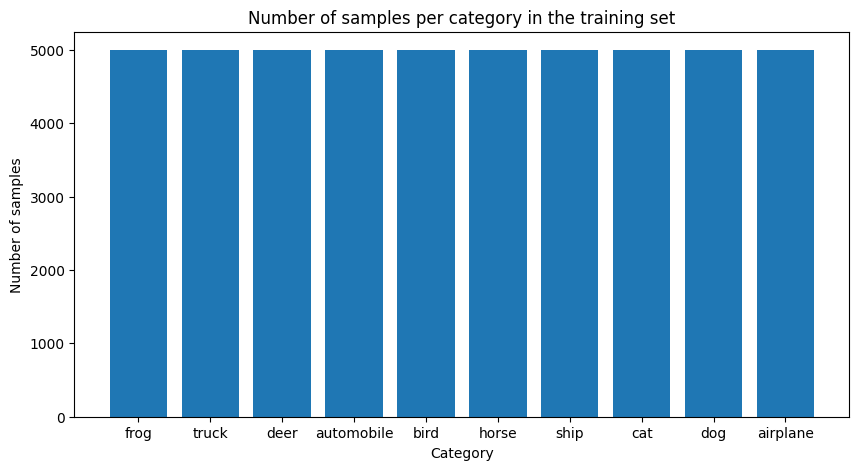

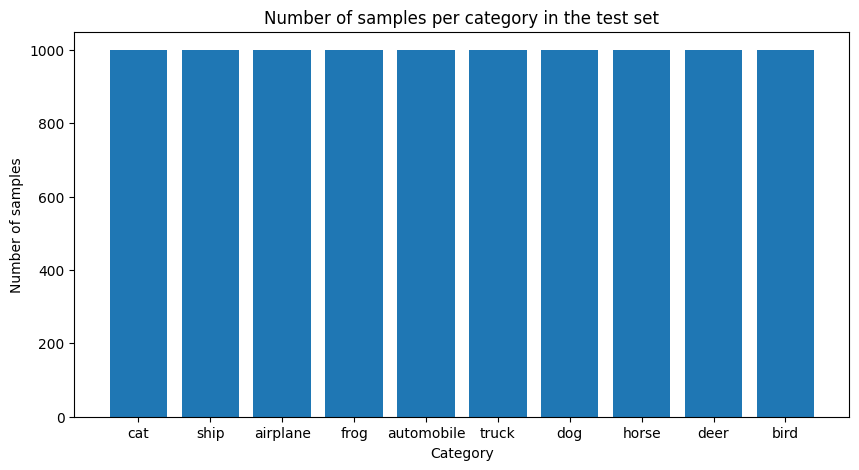

In [5]:
# Ex.1.2b your code here

# Plot the number of samples per category in the training set
plt.figure(figsize=(10, 5))
plt.bar(train_labels_count_named.keys(), train_labels_count_named.values())
plt.title('Number of samples per category in the training set')
plt.ylabel('Number of samples')
plt.xlabel('Category')


# Plot the number of samples per category in the test set
plt.figure(figsize=(10, 5))
plt.bar(test_labels_count_named.keys(), test_labels_count_named.values())
plt.title('Number of samples per category in the test set')
plt.ylabel('Number of samples')
plt.xlabel('Category')


**Reflection: Answer the below question**

Are you working with a balanced or an unbalanced dataset? Are there majoritarian classes? Do you think this will affect the later analysis and training of your models?

> Your Answer (Double click to edit): 
We work with a balanced dataset. Each category in both the training and the test sets contains an equal number of samples in the same category. So all classes are equal represented, there is no majoritarian classes. This will also not negatively affect the analysis or training. The model will not develop a bias towards any specific class (so we have fair training + reliable performance evaluation)

#### Exercise 1.3 - Visualize images in your dataset

Create a figure with n x 4 sub-plots. The value of 'n' depends on the number of categories present in the dataset.
As the title of each row in your figure, indicate the category it belongs to.

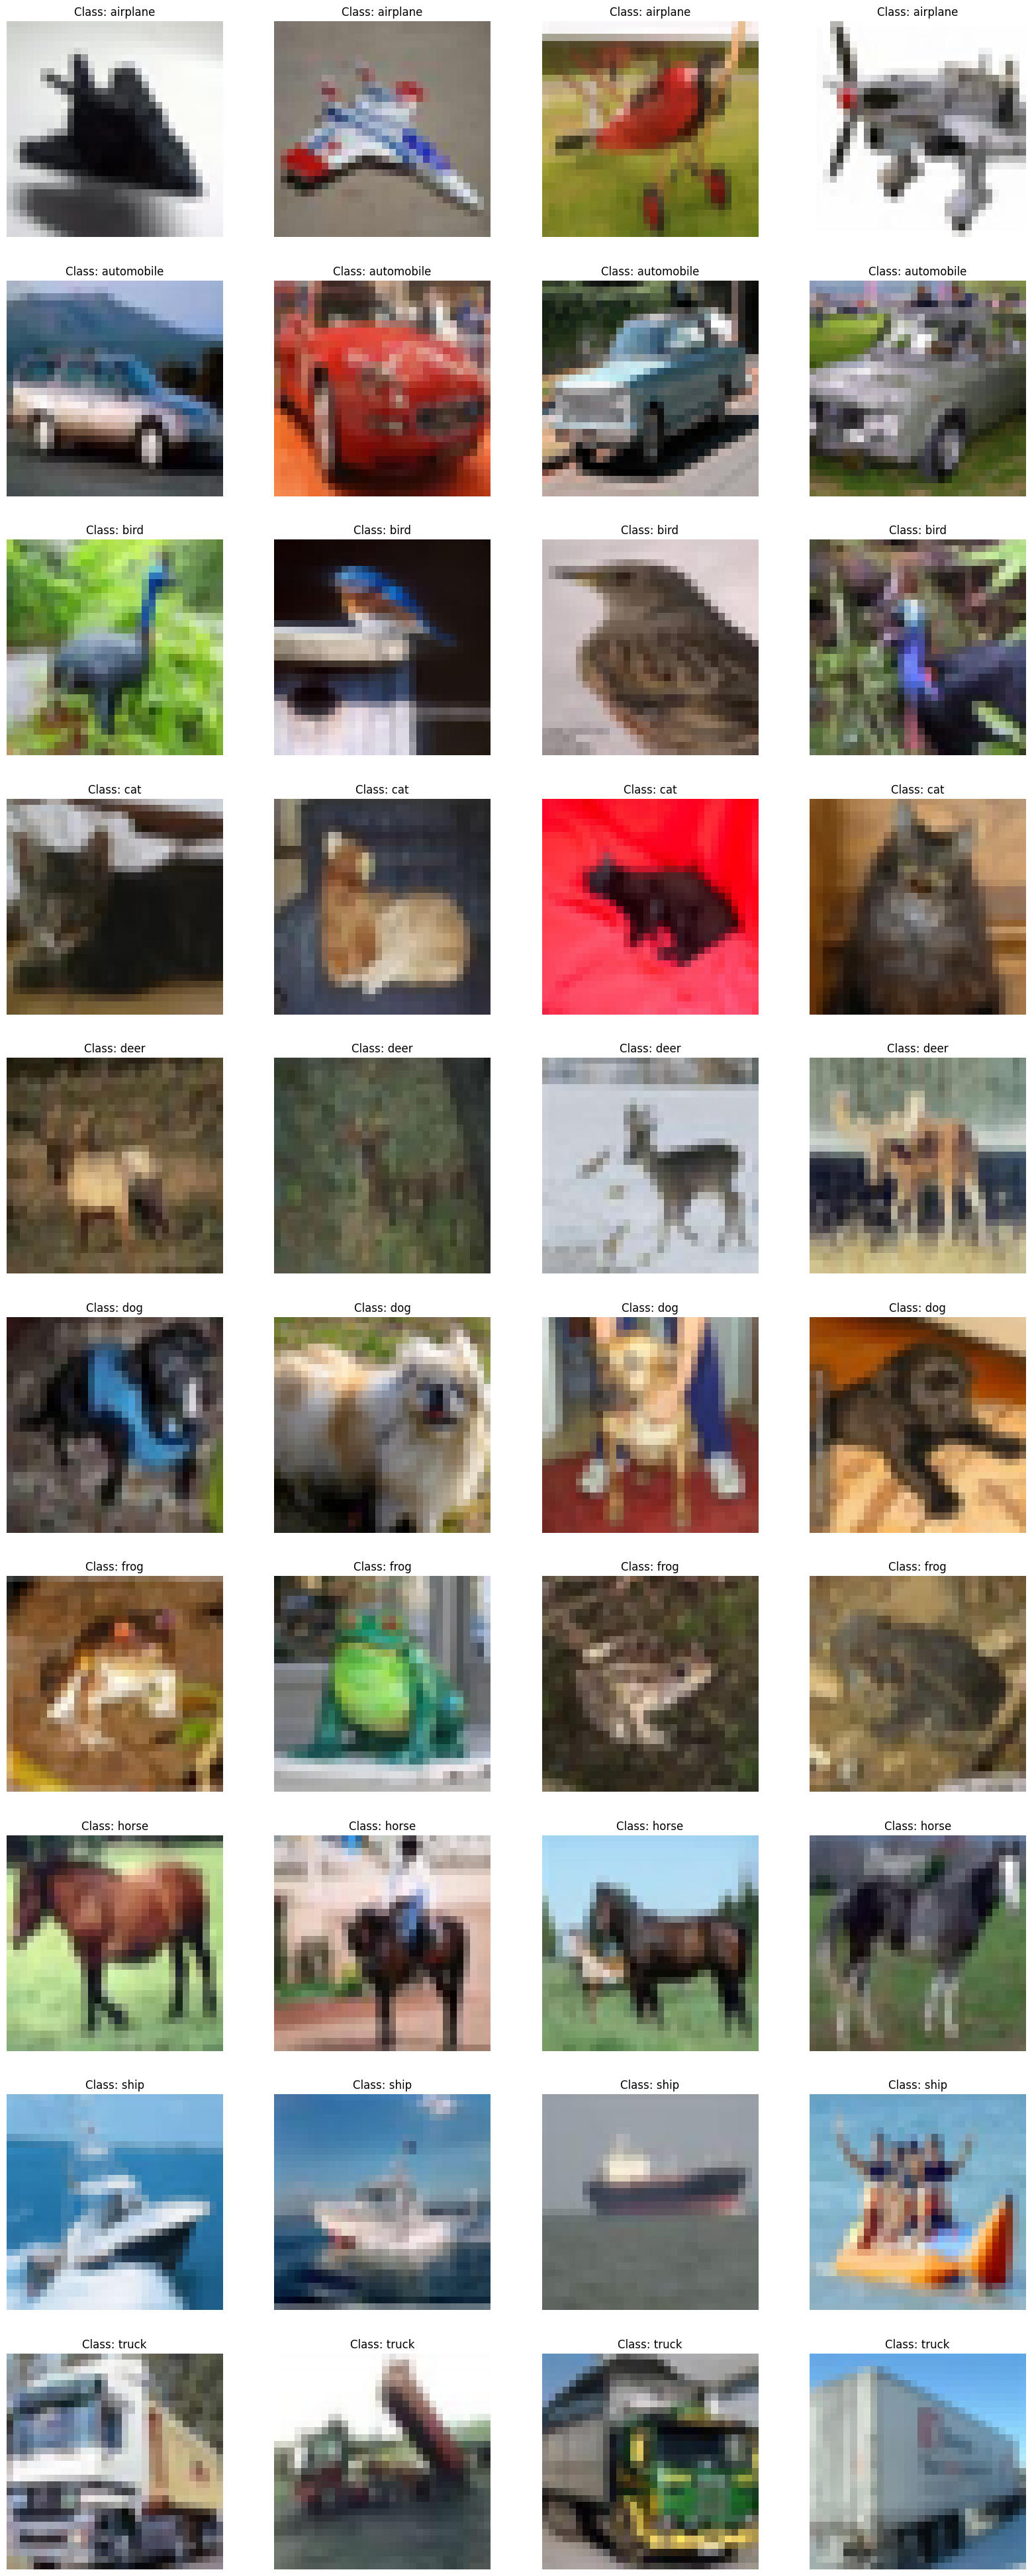

In [6]:
# Ex.1.3 your code here

# Create a figure with n x 4 sub-plots
n = len(classes)
fig, axs = plt.subplots(n, 4, figsize=(20, 5*n))
# Get the indices of the images for each category 
indices = [[i for i, label in enumerate(train_labels) if label == class_idx] for class_idx in range(n)]
# Plot the first 4 images of each category
for i in range(n):
    for j in range(4):
        image, label = trainset[indices[i][j]]
        axs[i, j].imshow(image)
        axs[i, j].set_title(f'Class: {classes[i]}')
        axs[i, j].axis('off')
plt.show()


#### Exercise 1.4 - RGB feature extraction

Extract RGB values from each image in your dataset as three seperate lists(one per channel). Each list should have 8 values. To do so, you can compute the histogram of each channel with 8 bins. Then you have to concatenate the values of all the three channels together resulting in a feature vector of size 24. This feature vector is the descriptor of an image in your dataset. You will have to do this for all the images present in your dataset in order to get the overall RGB descriptor which will be of size (n,24). Here 'n' depends on the number of samples present in the dataset. 

n= 5000

In [ ]:
# Ex.1.4 your code here

# Initialize an empty list to store the RGB descriptors for all images
rgb_descriptor = []

# Loop through each image in the training set
for image, label in trainset:
    # Convert image to a numpy array
    image_np = np.array(image)
    
    # Compute the histogram for each channel (R, G, B) with 8 bins
    r_hist, _ = np.histogram(image_np[:, :, 0], bins=8, range=(0, 256))
    g_hist, _ = np.histogram(image_np[:, :, 1], bins=8, range=(0, 256))
    b_hist, _ = np.histogram(image_np[:, :, 2], bins=8, range=(0, 256))
    
    # Concatenate the histograms to form a feature vector of size 24
    feature_vector = np.concatenate([r_hist, g_hist, b_hist])
    
    # Append the feature vector to the rgb_descriptor list
    rgb_descriptor.append(feature_vector)

# Convert the list to a numpy array
overall_rgb_descriptor = np.array(rgb_descriptor)
print(overall_rgb_descriptor)
print(f"Shape  of the RGB descriptor: {overall_rgb_descriptor.shape}")




[[  5  28  64 ...  25  22   5]
 [ 35 117 212 ... 131  91  92]
 [ 24 226 260 ...  26  30 285]
 ...
 [218 364 117 ...  52  64 235]
 [ 28  28  53 ... 197 180 310]
 [ 22  55 142 ... 106  53 132]]
Size  of the RGB descriptor: (50000, 24)


#### Exercise 1.5 - Compute the inter-class variability of your dataset.

Inter-class correlation aims at understanding the relationship/correlation among the classes/categories present in your dataset. For this, you could compute a measure (for example mean, std etc.) collectively for all the samples belonging to each and every class of the dataset. Then you could make use of this measure to find the correlation among the classes/categories using the standard pandas dataframe correlation function. Link: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html

Correlation matrix gives value between -1 and 1 
- 1: Perfect possitive correlation
- 0 : No correlation 
- -1: Perfect negative correlation 

In [ ]:
# Inter-class correlation aims at understanding the relationship/correlation among the classes/categories present in your dataset. For this, you could compute a measure (for example mean, std etc.) collectively for all the samples belonging to each and every class of the dataset. Then you could make use of this measure to find the correlation among the classes/categories using the standard pandas dataframe correlation function. Link: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html

# Ex.1.5 your code here

import pandas as pd

# Create a pandas DataFrame with the RGB descriptors
df = pd.DataFrame(overall_rgb_descriptor, columns=[i for i in range(24)])

# Add a column with the class labels
df['class'] = train_labels

# Compute the mean of the RGB descriptors for each class
mean_df = df.groupby('class').mean()

# Compute the correlation matrix
correlation_matrix = mean_df.corr()
print(correlation_matrix)


          0         1         2         3         4         5         6   \
0   1.000000  0.856893 -0.241771 -0.722060 -0.874161 -0.578459  0.145789   
1   0.856893  1.000000  0.109459 -0.495875 -0.790501 -0.862627 -0.140945   
2  -0.241771  0.109459  1.000000  0.788284  0.459657 -0.406107 -0.925079   
3  -0.722060 -0.495875  0.788284  1.000000  0.902101  0.157771 -0.758869   
4  -0.874161 -0.790501  0.459657  0.902101  1.000000  0.547358 -0.443138   
5  -0.578459 -0.862627 -0.406107  0.157771  0.547358  1.000000  0.459342   
6   0.145789 -0.140945 -0.925079 -0.758869 -0.443138  0.459342  1.000000   
7   0.529463  0.404062 -0.737746 -0.892030 -0.828128 -0.272238  0.666559   
8   0.886045  0.686961 -0.213067 -0.578729 -0.704223 -0.430268  0.077081   
9   0.722941  0.680230  0.092725 -0.322155 -0.534894 -0.530068 -0.178762   
10  0.061300  0.182191  0.758707  0.524245  0.244592 -0.309935 -0.742118   
11 -0.583042 -0.405096  0.815142  0.958123  0.839056  0.156532 -0.763075   
12 -0.861559

cel(3,4) = 0.902
Strong positive correlation
When Bin 3 increased, Bin 4 also increased.

cel(0,4) = -0.874
Strong negative correlation
When Bin 0 increased (has a high value), then the value in Bin 4 is mostly lower.

cel(6,9) = -0.179
Weak negative correlation
When there is a high value in Bin 6 (a lot of pixels), then there are slightly fewer pixels in Bin 9.

**c)** Compute the Silhouette score. 

The Silhouette score is used to assess the performance of using unsupervised machine learning (clustering). We can also use it here to assess the compactness of the extracted descriptors per category and for the group of categories as their mean.

You can use the function available in Sklearn - https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html

Silhoute Score: It ranges from -1 to +1:

- Positive values indicate that data points belong to the correct clusters, indicating good clustering results.
- A score of zero suggests overlapping clusters or data points equally close to multiple clusters.
- Negative values indicate that data points are assigned to incorrect clusters, indicating poor clustering results.

In [19]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Ex.1.5c your code here

from sklearn.metrics import silhouette_score

# Compute the Silhouette score for the RGB descriptors
silhouette_score_rgb = silhouette_score(overall_rgb_descriptor, train_labels)
print(f'Silhouette score for the RGB descriptors: {silhouette_score_rgb}')


Silhouette score for the RGB descriptors: -0.08492854865203082


**Reflection: (Answer the below questions)** 

**1.** Does Intra-class correlation score/coefficient help you assess the degree of similarity among the samples of a category?
> Yes, because it meassures the degree of similariy between the different categories. 

**2.** What can you deduce from the Inter-class correlation and Silhouette score?
> Your Answer (Double click to edit):  The Inter-class corelation measures how well different categories are distinguished. A low ICC indicates high overlap between categories, while a high ICC suggests well-separated categories.

The Silhouette Score assesses how well samples fit within their assigned clusters. A score close to 1 indicates well-defined and clearly separated clusters, while a score close to 0 or negative suggests overlapping and poorly defined clusters (make it better by optimize the number of clusters k).


#### Exercise 1.6 - Dimensionality reduction for visualization 

We can visualize large datasets having higher dimensions or features in 2- or 3-dimensional spaces. For this, you need to reduce the dimensionality of the data. 

In this exercise, you are asked to use PCA for reducing dimensionality.

Link to function to apply PCA: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

Create the following two figures:

**a)** Rely on the first 2 principal components to plot the samples of your dataset. Use one color per class.

**b)** Rely on the first 3 principal components to create a 3D plot. Use one color per class.

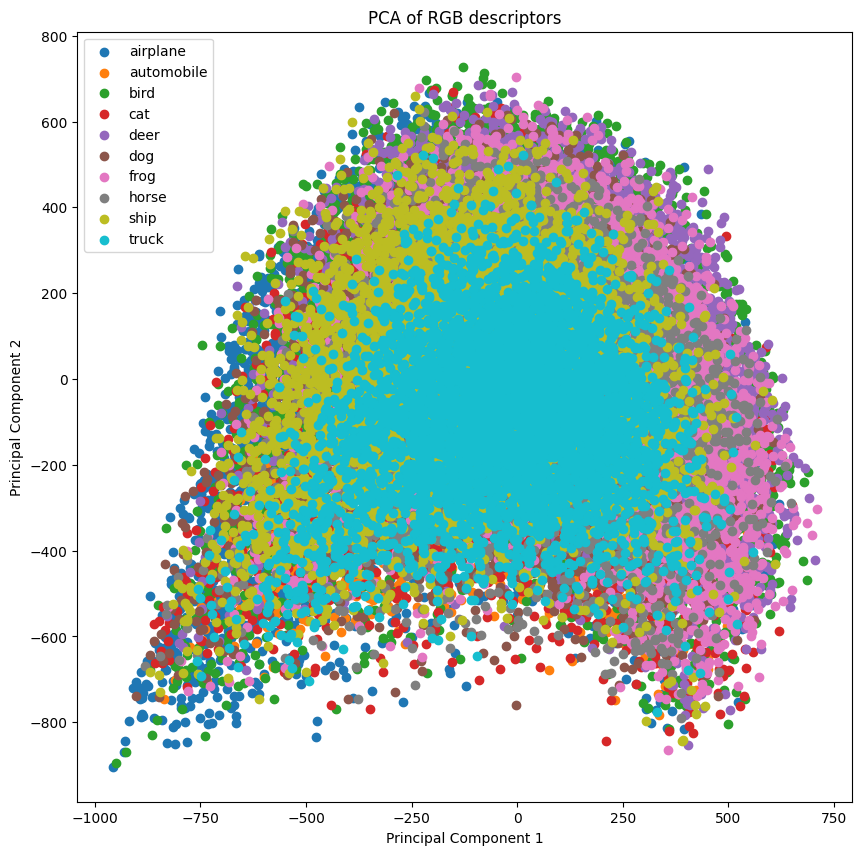

In [22]:
# Ex.1.6b your code here
# #### Exercise 1.6 - Dimensionality reduction for visualization 
# #### Exercise 1.6 - Dimensionality reduction for visualization 
# We can visualize large datasets having higher dimensions or features in 2- or 3-dimensional spaces. For this, you need to reduce the dimensionality of the data. 
# In this exercise, you are asked to use PCA for reducing dimensionality.
# Link to function to apply PCA: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html
# Create the following two figures:
# **a)** Rely on the first 2 principal components to plot the samples of your dataset. Use one color per class.

from sklearn.decomposition import PCA

# Apply PCA to the RGB descriptors
pca = PCA(n_components=2)
pca.fit(overall_rgb_descriptor)
pca_rgb_descriptor = pca.transform(overall_rgb_descriptor)

# Create a figure

plt.figure(figsize=(10, 10))
# Loop through each class
for i in range(n):
    # Get the indices of the samples for the current class
    indices = [j for j, label in enumerate(train_labels) if label == i]
    # Plot the samples of the current class
    plt.scatter(pca_rgb_descriptor[indices, 0], pca_rgb_descriptor[indices, 1], label=classes[i])
plt.legend()
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of RGB descriptors')
plt.show()





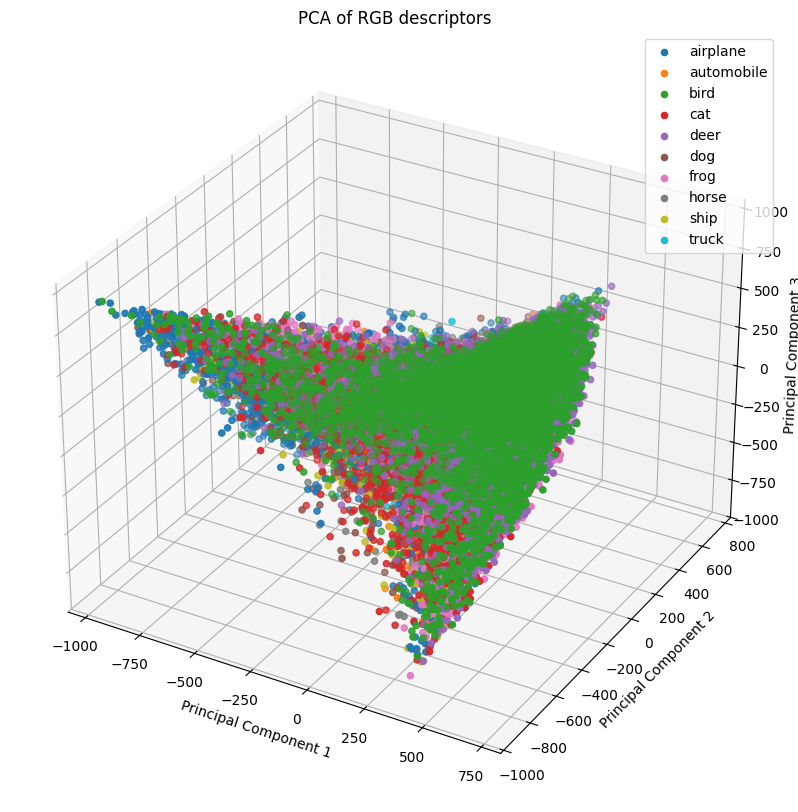

In [24]:
# Apply PCA to the RGB descriptors
pca = PCA(n_components=3)
pca.fit(overall_rgb_descriptor)
pca_rgb_descriptor = pca.transform(overall_rgb_descriptor)

# Create a 3D figure
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
# Loop through each class
for i in range(n):
    # Get the indices of the samples for the current class
    indices = [j for j, label in enumerate(train_labels) if label == i]
    # Plot the samples of the current class
    ax.scatter(pca_rgb_descriptor[indices, 0], pca_rgb_descriptor[indices, 1], pca_rgb_descriptor[indices, 2], label=classes[i])
ax.legend()
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.set_title('PCA of RGB descriptors')
plt.show()

#### Exercise 1.7 - Reflection

Reflect on the following questions.

**a)** Will you obtain the same visualisation in the feature space for different extracted features?
> Your Answer (Double click to edit): 

The two visualizations are based on the same dataset and the same features (RGB descriptors), but they differ in how the PCA results are represented. In the 2D visualization, only the first two principal components are plotted, while in the 3D visualization, the first three principal components are used. As a result, the 3D plot may retain more structural information, but the overall distribution and clustering of the classes should remain largely the same.
    
**b)** Are the classes distinguishable on the feature space when relying on PCA over RGB?
> Your Answer (Double click to edit): > 

The classes are not clearly distinguishable in the feature space when using PCA over RGB descriptors. The PCA projections show significant overlap between different classes, meaning that RGB alone may not provide enough discriminative power to separate them effectively.
    
**c)** What other visualization could you include to better describe your data?
> Your Answer (Double click to edit):  

Histograms or KDE Plots per Class: These can visualize how individual RGB values are distributed across different classes, helping to assess class distinctiveness.

Cluster Analysis (e.g., K-Means, DBSCAN): Running a clustering algorithm and visualizing the results could show how well the data naturally groups together, independent of labels.

#### [Optional] Exercise: Repeat experiments with different image descriptors

e.g. 
- Harris Corner Detection

- Shi-Tomasi Corner Detector and Good Features to Track

- Scale-Invariant Feature Transform (SIFT)

- Speeded-up robust features (SURF)

- Features from Accelerated Segment Test (FAST)

- Blob Detectors With LoG, DoG, and DoH

If you have OpenCV installed you can follow this example,
https://automaticaddison.com/image-feature-detection-description-and-matching-in-opencv/

When using Scikit-image,
https://scikit-image.org/docs/dev/api/skimage.feature.html?highlight=hog